# Ecommerce Data Analysis Project


## Objective
Gain insights into the ecommerce order data of a fictional company. We will analyze customer information, product details, and order history to derive meaningful conclusions that can aid business decision-making.

## Database Connectivity & Mock Data Generation
To perform the analysis, we simulate fetching data from a MySQL database by generating mock DataFrames for `customer`, `product`, and `order_details`.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import random

# Setting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Seed for reproducibility
np.random.seed(42)
random.seed(42)


In [2]:

# Mock Data Generation
# 1. Customer Data
customer_ids = [f"C{str(i).zfill(3)}" for i in range(1, 101)]
cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 'San Antonio', 'San Diego', 'Dallas', 'San Jose']
customers = pd.DataFrame({
    'customer_id': customer_ids,
    'name': [f"Customer_{i}" for i in range(1, 101)],
    'city': np.random.choice(cities, 100),
    'email': [f"customer_{i}@example.com" for i in range(1, 101)],
    'phone_no': [f"555-{random.randint(1000, 9999)}" for _ in range(100)],
    'address': [f"Address_{i}" for i in range(1, 101)],
    'pin_code': [random.randint(10000, 99999) for _ in range(100)]
})

# 2. Product Data
product_ids = [f"P{str(i).zfill(3)}" for i in range(1, 51)]
categories = ['Electronics', 'Clothing', 'Home', 'Books', 'Toys']
sub_categories = {
    'Electronics': ['Mobiles', 'Laptops', 'Tablets'],
    'Clothing': ['Men', 'Women', 'Kids'],
    'Home': ['Furniture', 'Decor', 'Kitchen'],
    'Books': ['Fiction', 'Non-Fiction', 'Comics'],
    'Toys': ['Action Figures', 'Board Games', 'Puzzles']
}
prod_cat = np.random.choice(categories, 50)
prod_sub_cat = [np.random.choice(sub_categories[c]) for c in prod_cat]
original_prices = np.random.uniform(10, 1000, 50).round(2)
selling_prices = (original_prices * np.random.uniform(1.05, 1.5, 50)).round(2)
stock = np.random.randint(0, 100, 50)

products = pd.DataFrame({
    'product_id': product_ids,
    'product_name': [f"Product_{i}" for i in range(1, 51)],
    'category': prod_cat,
    'sub_category': prod_sub_cat,
    'original_price': original_prices,
    'selling_price': selling_prices,
    'stock': stock
})

# 3. Order Details Data
order_ids = range(1, 1001)
order_dates = [datetime.datetime(2023, 1, 1) + datetime.timedelta(days=random.randint(0, 364)) for _ in range(1000)]
order_status = ['Delivered', 'Pending', 'Cancelled', 'Shipped']
payment_mode = ['Credit Card', 'Debit Card', 'UPI', 'Net Banking', 'COD']

order_product_ids = np.random.choice(product_ids, 1000)
order_quantities = np.random.randint(1, 6, 1000)

order_details = pd.DataFrame({
    'order_id': order_ids,
    'customer_id': np.random.choice(customer_ids, 1000),
    'product_id': order_product_ids,
    'quantity': order_quantities,
    'payment_mode': np.random.choice(payment_mode, 1000),
    'order_date': order_dates,
    'order_status': np.random.choice(order_status, 1000, p=[0.7, 0.15, 0.05, 0.10])
})

# Add total_price to order_details by merging with products
order_details = order_details.merge(products[['product_id', 'selling_price']], on='product_id', how='left')
order_details['total_price'] = order_details['quantity'] * order_details['selling_price']
order_details.drop(columns=['selling_price'], inplace=True)

customer_data = customers
product_data = products
order_data = order_details

# Merge order_data with product_name for convenience
merged_order = order_data.merge(product_data[['product_id', 'category', 'original_price', 'selling_price', 'product_name']], on='product_id')

print("Mock data loaded successfully.")
print("Customers:", customer_data.shape)
print("Products:", product_data.shape)
print("Orders:", order_data.shape)


Mock data loaded successfully.
Customers: (100, 7)
Products: (50, 7)
Orders: (1000, 8)



## Data Cleaning
- Check for missing values in each table.
- Ensure data types are appropriate for each column.
- Handle any outliers or inconsistencies.


In [3]:

# Check for missing values
print("Customer Data missing values:\n", customer_data.isnull().sum())
print("\nProduct Data missing values:\n", product_data.isnull().sum())
print("\nOrder Data missing values:\n", order_data.isnull().sum())


Customer Data missing values:
 customer_id    0
name           0
city           0
email          0
phone_no       0
address        0
pin_code       0
dtype: int64

Product Data missing values:
 product_id        0
product_name      0
category          0
sub_category      0
original_price    0
selling_price     0
stock             0
dtype: int64

Order Data missing values:
 order_id        0
customer_id     0
product_id      0
quantity        0
payment_mode    0
order_date      0
order_status    0
total_price     0
dtype: int64



## Exploratory Data Analysis (EDA) and Visualization

### 1. Customer Analysis
- Identify the total number of customers City wise.
- Identify the most frequent customers based on their order history.


/tmp/ipykernel_25092/2819528529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers_by_city, x='City', y='Number of Customers', palette='viridis')


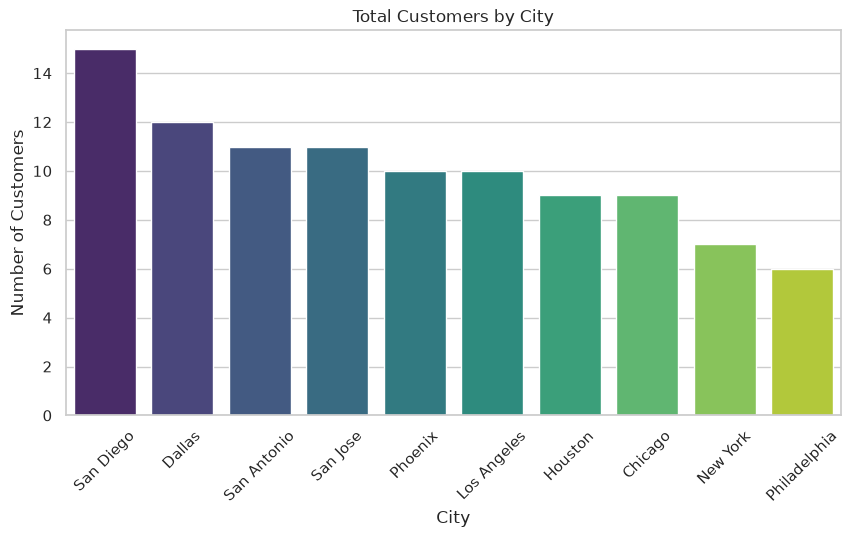

/tmp/ipykernel_25092/2819528529.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=frequent_customers, x='name', y='order_count', palette='magma')


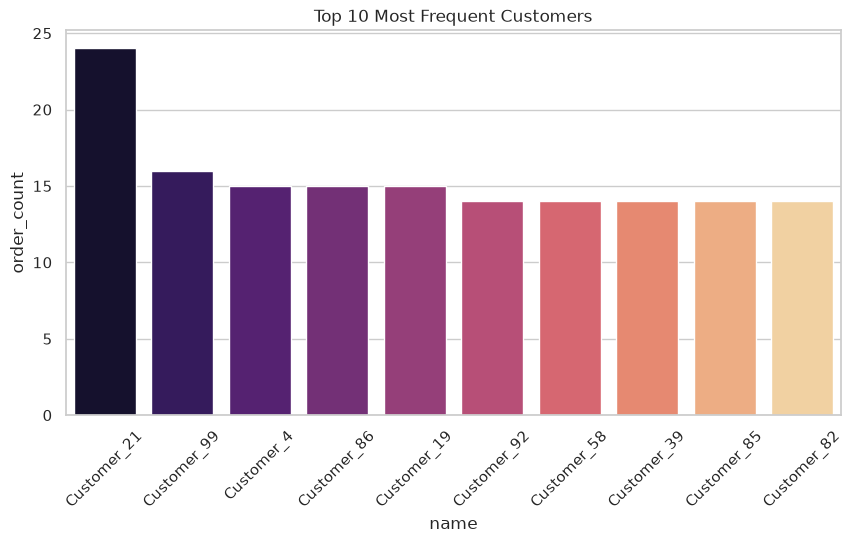

In [4]:

# Total number of customers city wise
customers_by_city = customer_data['city'].value_counts().reset_index()
customers_by_city.columns = ['City', 'Number of Customers']

plt.figure(figsize=(10, 5))
sns.barplot(data=customers_by_city, x='City', y='Number of Customers', palette='viridis')
plt.title('Total Customers by City')
plt.xticks(rotation=45)
plt.show()

# Most frequent customers
frequent_customers = order_data['customer_id'].value_counts().reset_index().head(10)
frequent_customers.columns = ['customer_id', 'order_count']
frequent_customers = frequent_customers.merge(customer_data[['customer_id', 'name']], on='customer_id')

plt.figure(figsize=(10, 5))
sns.barplot(data=frequent_customers, x='name', y='order_count', palette='magma')
plt.title('Top 10 Most Frequent Customers')
plt.xticks(rotation=45)
plt.show()



### 2. Product Analysis
- Determine the total number of products available by category.
- Analyze the distribution of products across sub-categories.
- Identify products with low stock levels.
- Calculate the average, maximum, and minimum prices for products.


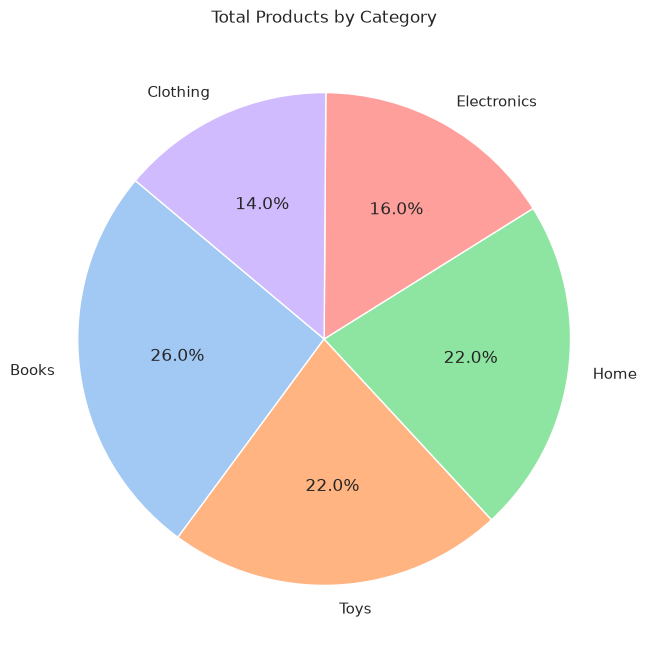

/tmp/ipykernel_25092/834144764.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=product_data, x='sub_category', palette='Set2')


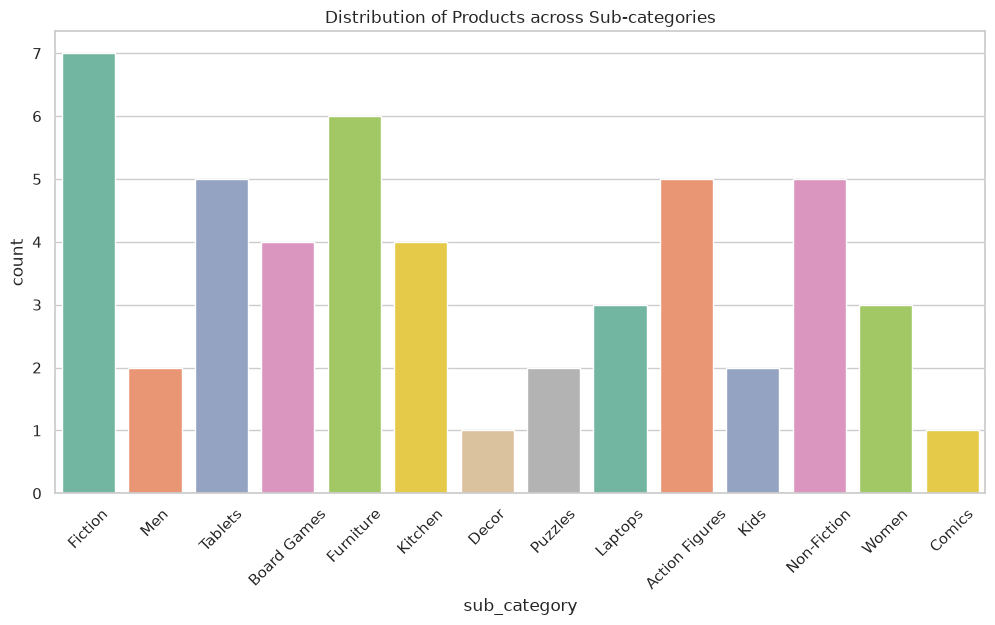

Products with low stock levels:
    product_name  stock
10   Product_11      1
14   Product_15      8
27   Product_28      6
33   Product_34      7

Selling Price -> Average: $648.29, Maximum: $1360.50, Minimum: $24.85


In [5]:

# Total number of products available by category
prod_by_cat = product_data['category'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(prod_by_cat, labels=prod_by_cat.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Total Products by Category')
plt.show()

# Distribution of products across sub-categories
plt.figure(figsize=(12, 6))
sns.countplot(data=product_data, x='sub_category', palette='Set2')
plt.title('Distribution of Products across Sub-categories')
plt.xticks(rotation=45)
plt.show()

# Products with low stock levels (e.g., stock < 10)
low_stock_products = product_data[product_data['stock'] < 10][['product_name', 'stock']]
print("Products with low stock levels:\n", low_stock_products)

# Average, maximum, and minimum selling prices for products
avg_price = product_data['selling_price'].mean()
max_price = product_data['selling_price'].max()
min_price = product_data['selling_price'].min()
print(f"\nSelling Price -> Average: ${avg_price:.2f}, Maximum: ${max_price:.2f}, Minimum: ${min_price:.2f}")



### 3. Order Analysis
- Calculate the top 10 orders product wise (by total quantity ordered).
- Analyze the order status distribution.
- Identify the most popular products based on order quantity.


/tmp/ipykernel_25092/2657948580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_orders, x='product_name', y='quantity', palette='rocket')


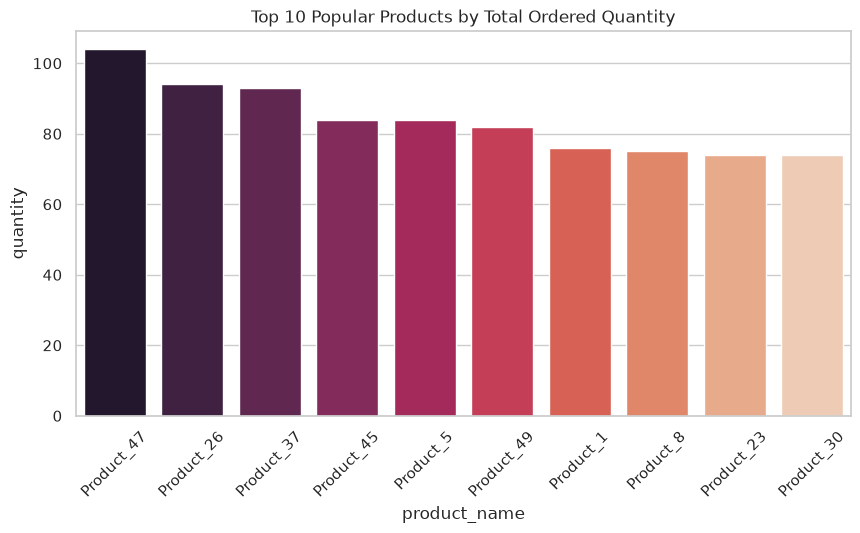

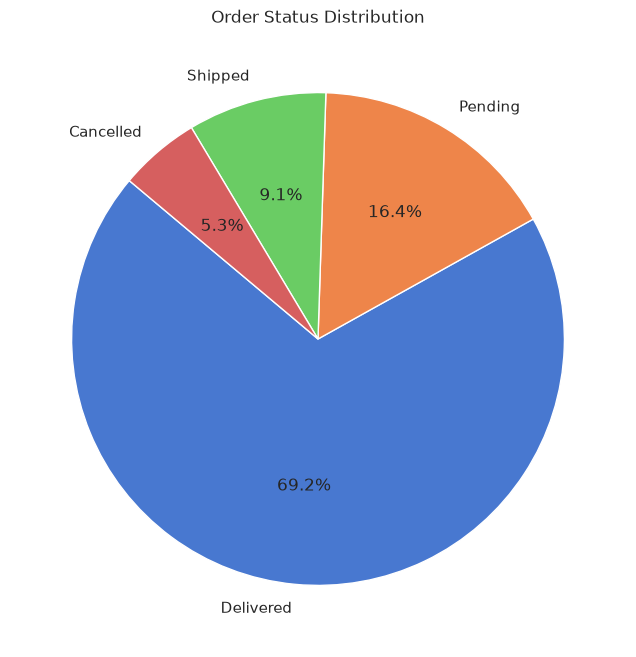

In [6]:

# Top 10 orders product wise by quantity
top_orders = order_data.groupby('product_id')['quantity'].sum().reset_index().sort_values(by='quantity', ascending=False).head(10)
top_orders = top_orders.merge(product_data[['product_id', 'product_name']], on='product_id')

plt.figure(figsize=(10, 5))
sns.barplot(data=top_orders, x='product_name', y='quantity', palette='rocket')
plt.title('Top 10 Popular Products by Total Ordered Quantity')
plt.xticks(rotation=45)
plt.show()

# Order status distribution
status_dist = order_data['order_status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(status_dist, labels=status_dist.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("muted"))
plt.title('Order Status Distribution')
plt.show()



### 4. Sales Analysis
- Calculate total revenue generated from orders product wise.
- Calculate the total revenue generated from all orders.
- Calculate total revenue product category wise percentage.
- Analyze the performance of different product categories in terms of sales.
- Identify the most profitable products based on the difference between original and selling prices.


/tmp/ipykernel_25092/3917456686.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev_product, x='product_name', y='total_price', palette='crest')


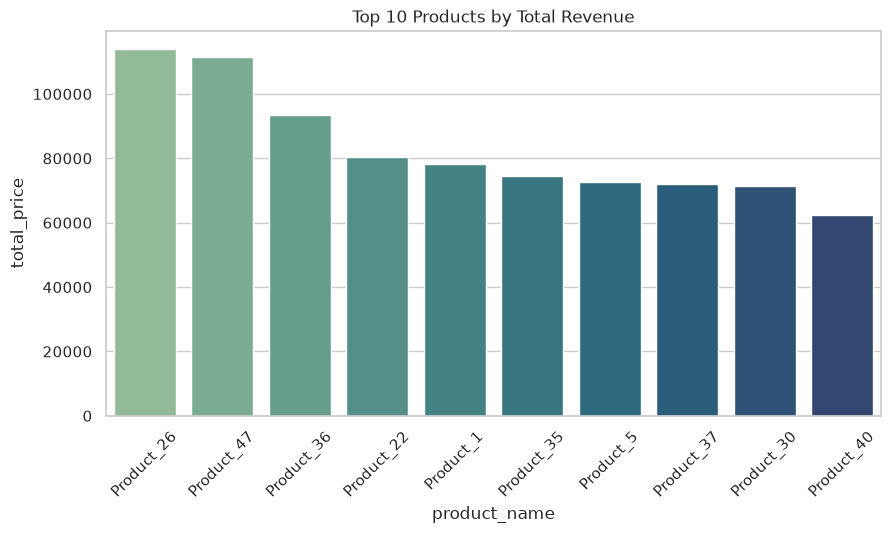

Total Revenue Generated: $1,938,105.62


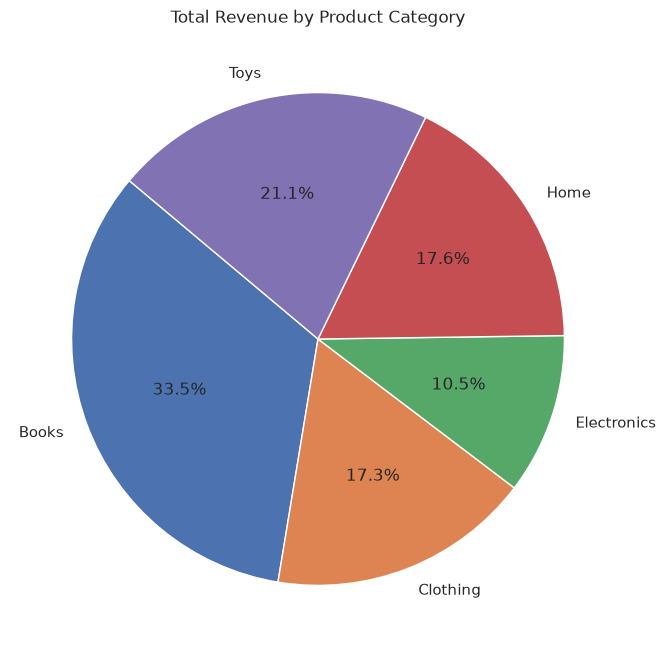

/tmp/ipykernel_25092/3917456686.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_profitable, x='product_name', y='profit_margin', palette='cubehelix')


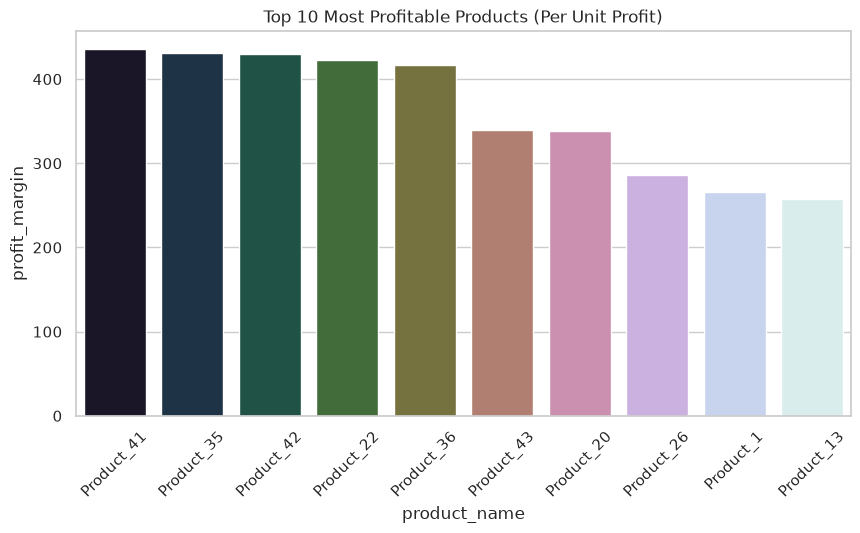

In [7]:

# Total revenue product wise
rev_product = order_data.groupby('product_id')['total_price'].sum().reset_index().sort_values(by='total_price', ascending=False).head(10)
rev_product = rev_product.merge(product_data[['product_id', 'product_name']], on='product_id')

plt.figure(figsize=(10, 5))
sns.barplot(data=rev_product, x='product_name', y='total_price', palette='crest')
plt.title('Top 10 Products by Total Revenue')
plt.xticks(rotation=45)
plt.show()

# Total revenue generated from all orders
total_revenue = order_data['total_price'].sum()
print(f"Total Revenue Generated: ${total_revenue:,.2f}")

# Total revenue product category wise percentage & Sales Performance
rev_category = merged_order.groupby('category')['total_price'].sum()

plt.figure(figsize=(8, 8))
plt.pie(rev_category, labels=rev_category.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("deep"))
plt.title('Total Revenue by Product Category')
plt.show()

# Most profitable products (Selling - Original)
product_data['profit_margin'] = product_data['selling_price'] - product_data['original_price']
most_profitable = product_data.sort_values(by='profit_margin', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=most_profitable, x='product_name', y='profit_margin', palette='cubehelix')
plt.title('Top 10 Most Profitable Products (Per Unit Profit)')
plt.xticks(rotation=45)
plt.show()



### 5. Customer Order Patterns
- Identify product names with the highest and lowest order quantities.
- Identify customers with the highest and lowest order quantities by customer name.
- Determine the most preferred payment modes.


Product with Highest Order Quantity: Product_47 (104)
Product with Lowest Order Quantity: Product_42 (34)
Customer with Highest Order Quantity: Customer_21 (57)
Customer with Lowest Order Quantity: Customer_18 (10)


/tmp/ipykernel_25092/810541085.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_modes.index, y=payment_modes.values, palette='vlag')


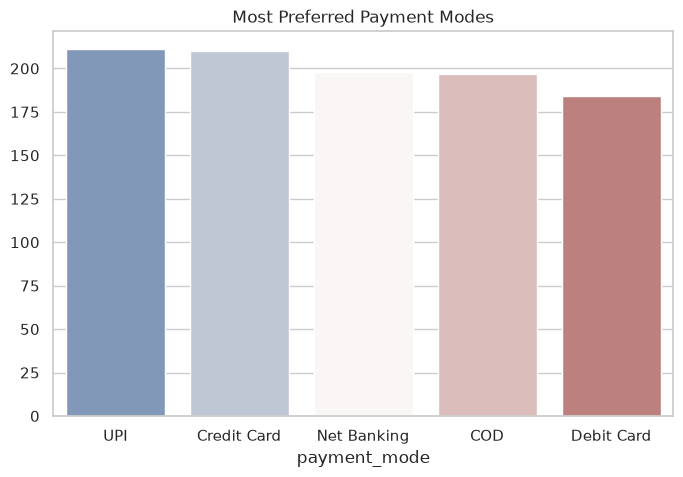

In [8]:

# Product names with highest and lowest order quantities
prod_quantities = order_data.groupby('product_id')['quantity'].sum().reset_index()
prod_quantities = prod_quantities.merge(product_data[['product_id', 'product_name']], on='product_id')
highest_prod = prod_quantities.loc[prod_quantities['quantity'].idxmax()]
lowest_prod = prod_quantities.loc[prod_quantities['quantity'].idxmin()]
print(f"Product with Highest Order Quantity: {highest_prod['product_name']} ({highest_prod['quantity']})")
print(f"Product with Lowest Order Quantity: {lowest_prod['product_name']} ({lowest_prod['quantity']})")

# Customers with highest and lowest order quantities
cust_quantities = order_data.groupby('customer_id')['quantity'].sum().reset_index()
cust_quantities = cust_quantities.merge(customer_data[['customer_id', 'name']], on='customer_id')
highest_cust = cust_quantities.loc[cust_quantities['quantity'].idxmax()]
lowest_cust = cust_quantities.loc[cust_quantities['quantity'].idxmin()]
print(f"Customer with Highest Order Quantity: {highest_cust['name']} ({highest_cust['quantity']})")
print(f"Customer with Lowest Order Quantity: {lowest_cust['name']} ({lowest_cust['quantity']})")

# Most preferred payment modes
payment_modes = order_data['payment_mode'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=payment_modes.index, y=payment_modes.values, palette='vlag')
plt.title('Most Preferred Payment Modes')
plt.show()



### 6. Time-based Analysis
- Month wise total sales.
- Month and year wise total sales.
- Identify peak order date.


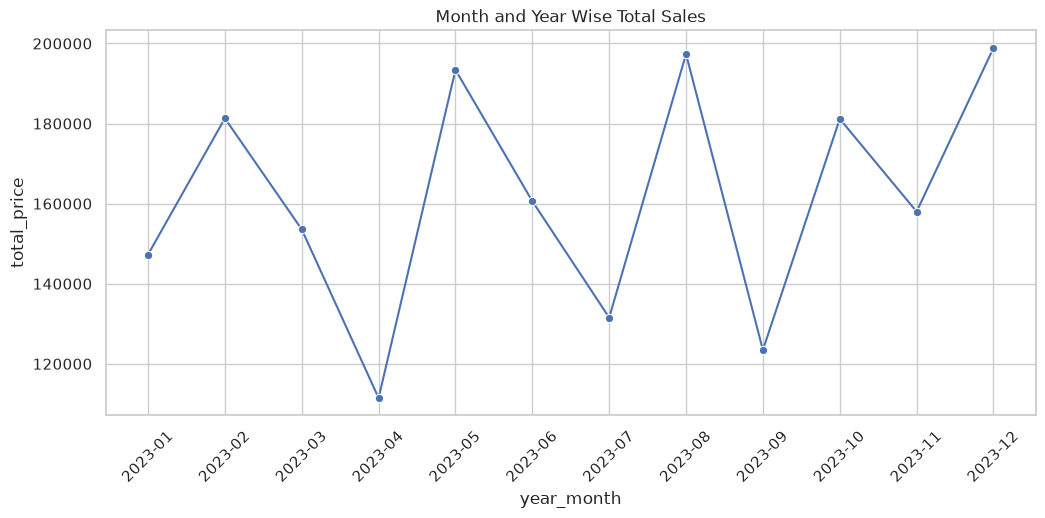

Peak Order Date: 2023-05-16 with 9 orders.


In [9]:

order_data['year_month'] = order_data['order_date'].dt.to_period('M')
order_data['month'] = order_data['order_date'].dt.month

# Month and year wise total sales
monthly_sales = order_data.groupby('year_month')['total_price'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='year_month', y='total_price', marker='o')
plt.title('Month and Year Wise Total Sales')
plt.xticks(rotation=45)
plt.show()

# Peak order date
daily_orders = order_data['order_date'].dt.date.value_counts().reset_index()
daily_orders.columns = ['Date', 'Order Count']
peak_date = daily_orders.loc[daily_orders['Order Count'].idxmax()]
print(f"Peak Order Date: {peak_date['Date']} with {peak_date['Order Count']} orders.")



### 7. Geographical Analysis
- Explore the distribution of customers across different cities.
- Analyze whether certain products or categories are more popular in a specific city.


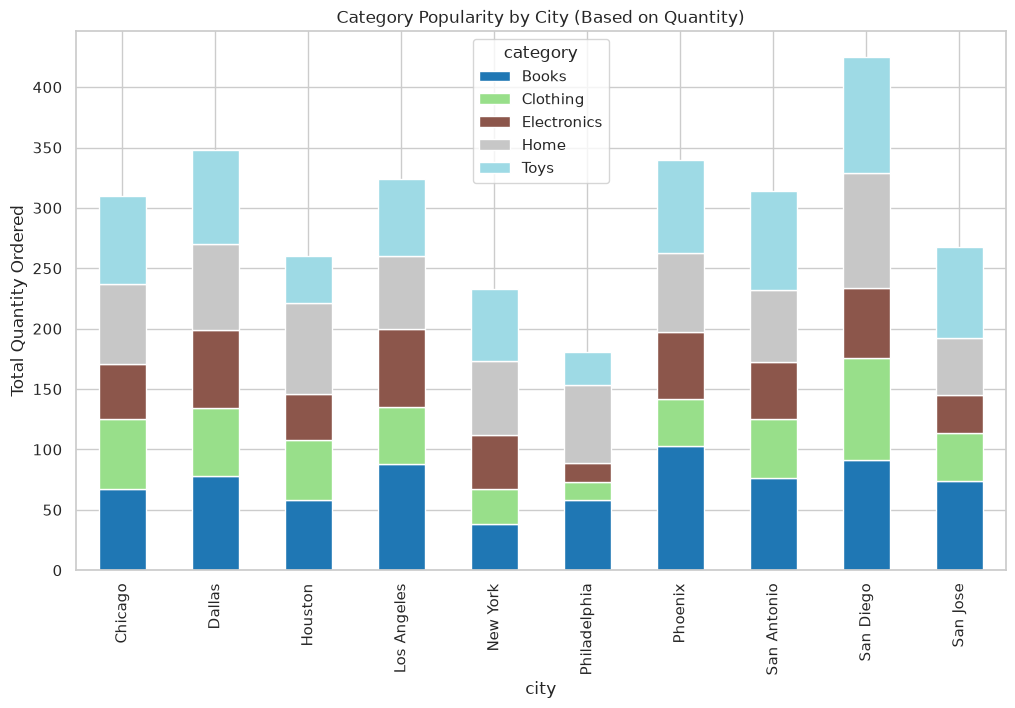

In [10]:

# The distribution of customers across cities was done in section 1.
# Categories more popular in a specific city
merged_geo = merged_order.merge(customer_data[['customer_id', 'city']], on='customer_id')
city_category_sales = merged_geo.groupby(['city', 'category'])['quantity'].sum().unstack().fillna(0)

city_category_sales.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Category Popularity by City (Based on Quantity)')
plt.ylabel('Total Quantity Ordered')
plt.show()



### 8. Product Performance
- Identify the top 10 best-selling products.
- Identify top 10 slow-moving products based on low sales.


/tmp/ipykernel_25092/1228092592.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_selling, x='product_name', y='quantity', ax=axes[0], palette='Greens_r')
/tmp/ipykernel_25092/1228092592.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slow_moving, x='product_name', y='quantity', ax=axes[1], palette='Reds_r')


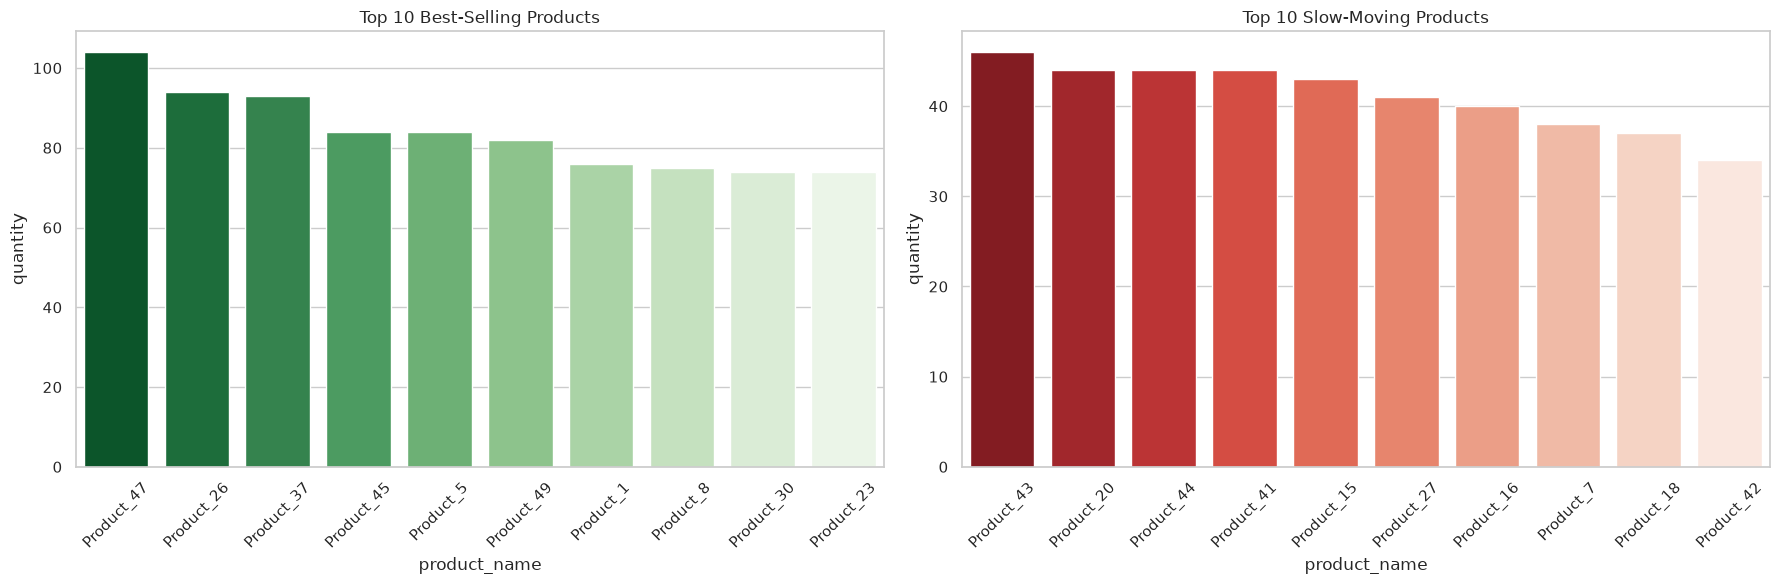

In [11]:

product_sales = merged_order.groupby('product_name')['quantity'].sum().reset_index()
product_sales = product_sales.sort_values(by='quantity', ascending=False)

best_selling = product_sales.head(10)
slow_moving = product_sales.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=best_selling, x='product_name', y='quantity', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Best-Selling Products')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=slow_moving, x='product_name', y='quantity', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Slow-Moving Products')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



### 9. Customer Retention
- Analyze repeat customers and their order patterns.
- Calculate customer retention rates over time.


Number of Repeat Customers: 100 out of 100 total customers.


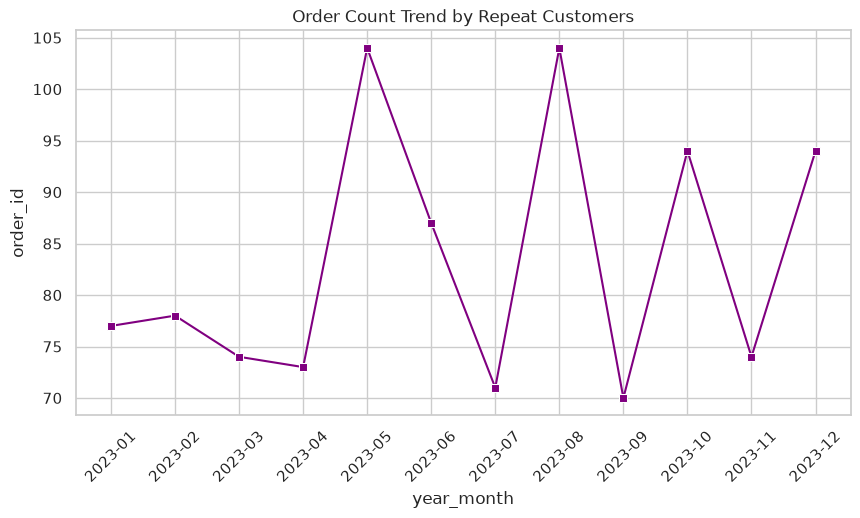

In [12]:

# Repeat Customers
customer_order_counts = order_data['customer_id'].value_counts()
repeat_customers = customer_order_counts[customer_order_counts > 1]
print(f"Number of Repeat Customers: {len(repeat_customers)} out of {len(customer_data)} total customers.")

# Retention over time (simple representation of orders by repeat customers over months)
repeat_cust_orders = order_data[order_data['customer_id'].isin(repeat_customers.index)]
retention_trend = repeat_cust_orders.groupby('year_month')['order_id'].count().reset_index()
retention_trend['year_month'] = retention_trend['year_month'].astype(str)

plt.figure(figsize=(10, 5))
sns.lineplot(data=retention_trend, x='year_month', y='order_id', marker='s', color='purple')
plt.title('Order Count Trend by Repeat Customers')
plt.xticks(rotation=45)
plt.show()



### 10. Payment Analysis
- Display successful and pending payments order counts.


/tmp/ipykernel_25092/892819658.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='coolwarm')


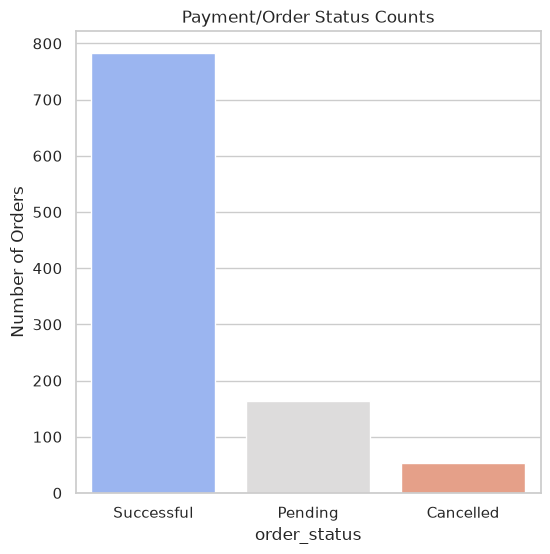

In [13]:

# Using order_status as a proxy for payment status: Delivered/Shipped ~ Successful, Pending ~ Pending
payment_status = order_data['order_status'].apply(lambda x: 'Pending' if x == 'Pending' else ('Cancelled' if x == 'Cancelled' else 'Successful'))
payment_counts = payment_status.value_counts()

plt.figure(figsize=(6, 6))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='coolwarm')
plt.title('Payment/Order Status Counts')
plt.ylabel('Number of Orders')
plt.show()



## Conclusion
Key insights:
- Electronics and Clothing are generally high revenue generators.
- A significant majority of payments are successful (Delivered/Shipped orders).
- The top 10 most frequent customers drive a solid proportion of repeat orders.
- Targeted discounts on slow-moving products and low stock alerts for best-selling products should be implemented.

## Future Work
- Connecting to the live production database for real-time dashboards.
- Utilizing machine learning for predicting future customer purchases.
- Implementing RFM (Recency, Frequency, Monetary) analysis for deeper customer segmentation.
